In [1]:
import pickle

# Load the pickle file
with open('../network_data.pkl', 'rb') as f:
    data = pickle.load(f)

In [2]:
print(data)

{'nodes': [{'id': '134', 'group': 'Consensus (hard fork)', 'compliance_score': 82.35, 'created': '2016-07-27', 'author': ['Tom Zander <tomz@freedommail.ch>'], 'word_list': {'transaction': 32, 'we': 24, 'transactions': 16, 'format': 15, 'can': 15, 'input': 15, 'not': 14, 'tokens': 12, 'signatures': 12, 'future': 10, 'all': 9, 'new': 9, 'data': 9, 'have': 9, 'amount': 9, 'any': 9, 'version': 8, 'like': 8, 'fields': 8, 'they': 8, 'optional': 8, 'hash': 8, 'bitcoin': 7, 'use': 7, 'name': 7, 'spec': 7, 'without': 7, 'if': 7, 'bip': 6, 'flexible': 6, '4': 6, '0': 6, 'token': 6, 'which': 6, 'means': 6, 'integer': 6, 'order': 6, 'id': 6, 'spending': 6, 'bytearray': 6, 'used': 6, 'https': 5, 'github': 5, 'com': 5, 'following': 5, 'cmf': 5, 'based': 5, 'value': 5, 'after': 5, 'blob': 5, 'part': 5, 'tx': 5, 'signature': 5, 'v4': 5, 'txend': 5, 'implementation': 5, 'comments': 4, 'type': 4, 'next': 4, 'same': 4, 'time': 4, 'malleability': 4, 'message': 4, 'where': 4, 'because': 4, 'added': 4, 'upg

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

In [4]:
import json
import networkx as nx

def compute_and_store_layout(data, filename="fixed_layout.json"):
    G = nx.DiGraph()
    for node in data['nodes']:
        G.add_node(node['id'])
    for link in data['links'].get('references', []):
        G.add_edge(link['source'], link['target'], weight=1)

    pos = nx.spring_layout(G, k=3.5, iterations=300, seed=42, weight='weight')

    # Convert numpy arrays to lists
    pos_serializable = {n: pos[n].tolist() for n in pos}

    with open(filename, "w") as f:
        json.dump(pos_serializable, f, indent=2)

    return pos

In [5]:
compute_and_store_layout(data)

{'134': array([-0.23357035,  0.84932861]),
 '71': array([0.82407528, 0.19333963]),
 '88': array([ 0.09366754, -0.03326505]),
 '122': array([-0.9223145,  0.2865102]),
 '67': array([0.11824114, 0.59692903]),
 '175': array([-0.1154857 ,  0.36095309]),
 '30': array([ 0.69211642, -0.6221741 ]),
 '159': array([-0.73220624, -0.71613947]),
 '118': array([0.1880722 , 0.29751395]),
 '374': array([ 0.23030706, -0.53793835]),
 '180': array([ 0.21106012, -0.82071949]),
 '342': array([-0.1095091 ,  0.33907443]),
 '84': array([0.29752596, 0.41407906]),
 '179': array([-0.97698043, -0.00871577]),
 '381': array([-0.03606932, -1.        ]),
 '47': array([ 0.35265288, -0.4302897 ]),
 '102': array([-0.55119288,  0.73568639]),
 '339': array([0.75368766, 0.4016052 ]),
 '10': array([-0.53704421, -0.87166727]),
 '155': array([ 0.82249717, -0.31852143]),
 '143': array([-0.71880968,  0.1335066 ]),
 '114': array([-0.59844996,  0.58301496]),
 '50': array([-0.62782369,  0.64958369]),
 '115': array([-0.75562568,  0.

In [6]:
import numpy as np

In [7]:
def draw_static_network(data, link_type='references', layout_file="fixed_layout.json"):
    import json

    G = nx.DiGraph()

    # Add nodes
    for node in data['nodes']:
        G.add_node(node['id'])

    # Add edges
    for link in data['links'].get(link_type, []):
        G.add_edge(link['source'], link['target'], weight=1)

    # Load fixed layout
    with open(layout_file, "r") as f:
        pos = json.load(f)

    # Convert list -> numpy array for NetworkX
    pos = {n: np.array(pos[n]) for n in pos}

    # In-degree dict
    in_degrees = dict(G.in_degree())

    # Node sizes
    min_size, max_size = 300, 3000
    max_in = max(in_degrees.values()) if in_degrees else 1
    if max_in == 0:
        max_in = 1
    
    node_sizes = [
        min_size + (in_degrees[n] / max_in) * (max_size - min_size)
        for n in G.nodes
    ]

    # Plot
    plt.figure(figsize=(12, 8))
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue', alpha=0.85)
    nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle='->', alpha=0.3)
    nx.draw_networkx_labels(G, pos, font_size=8)

    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f"bip_network_{link_type}.pdf", dpi=300, bbox_inches='tight')
    plt.show()


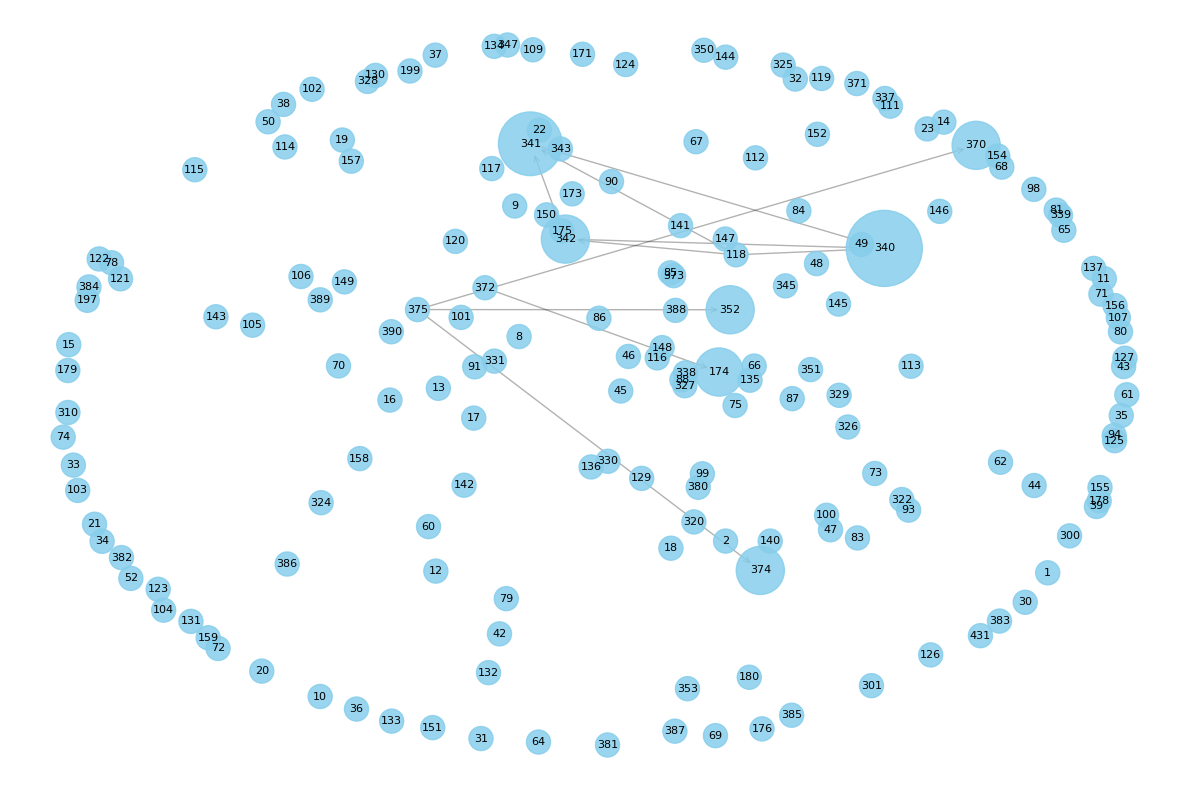

In [8]:
draw_static_network(data, link_type='requires')

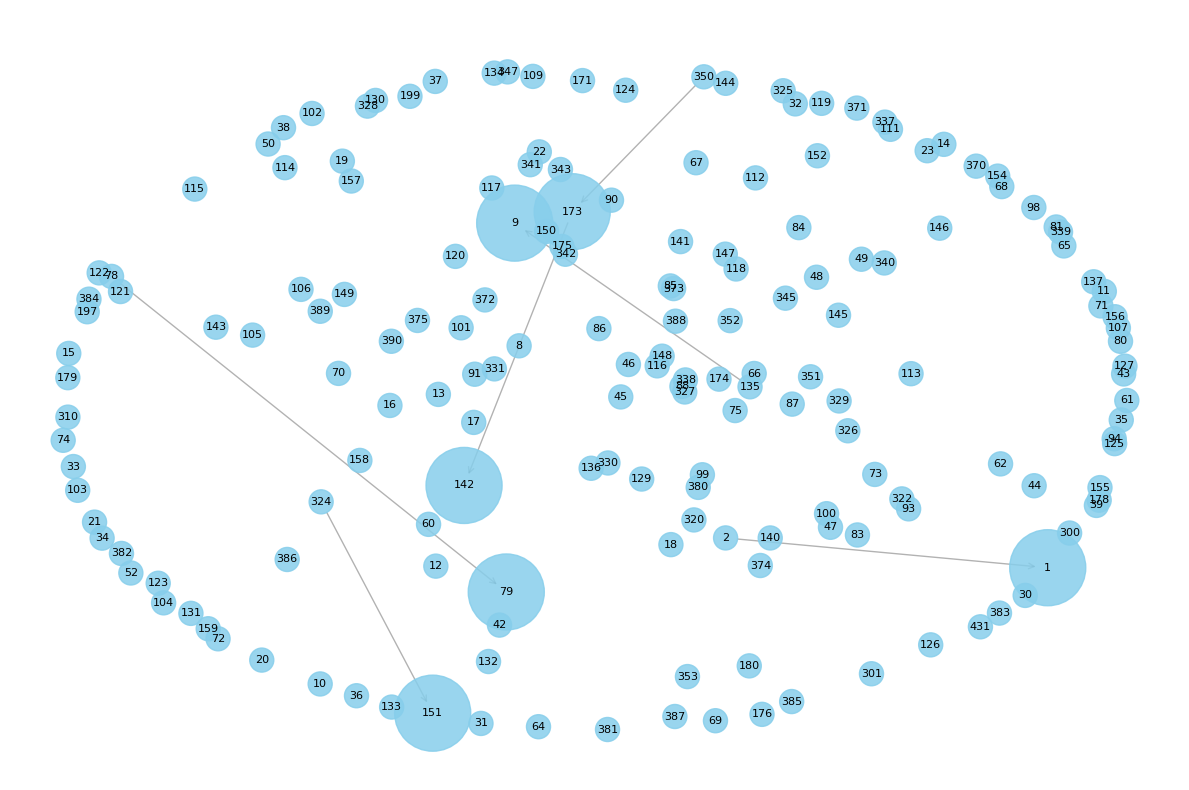

In [9]:
draw_static_network(data, link_type='replaces')

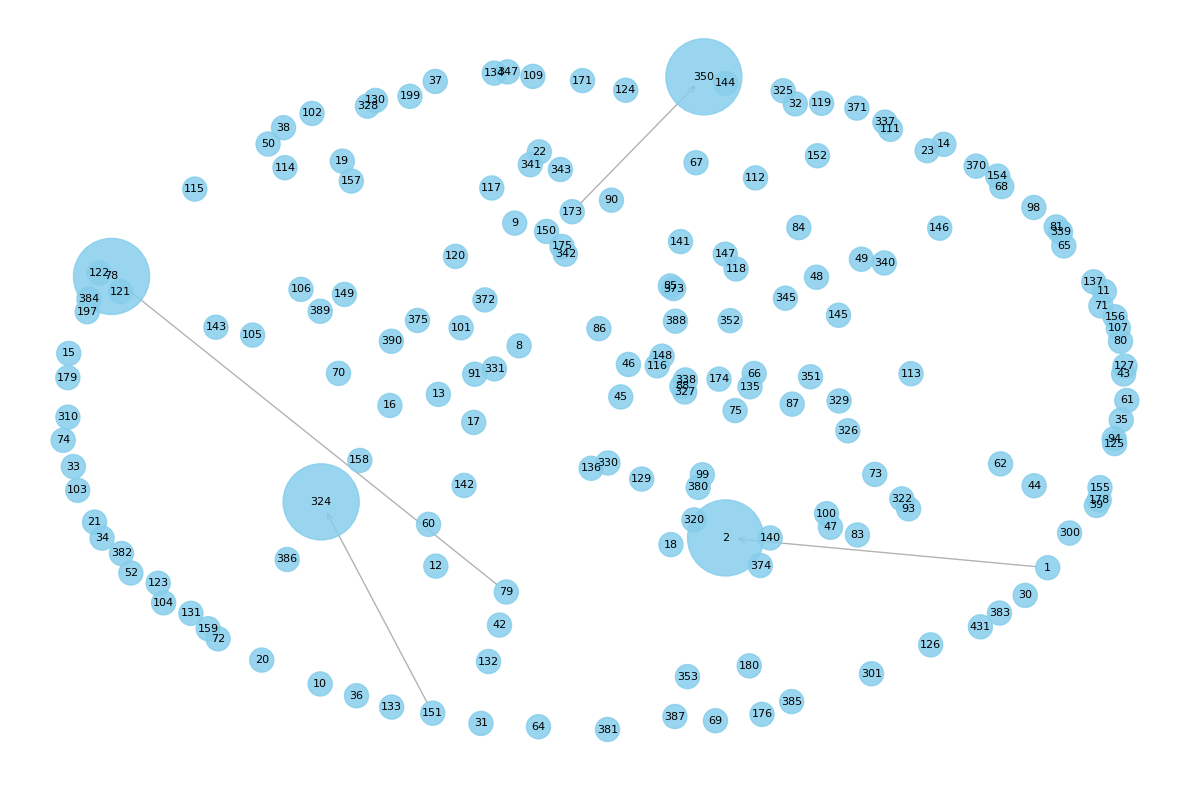

In [10]:
draw_static_network(data, link_type='superseded_by')

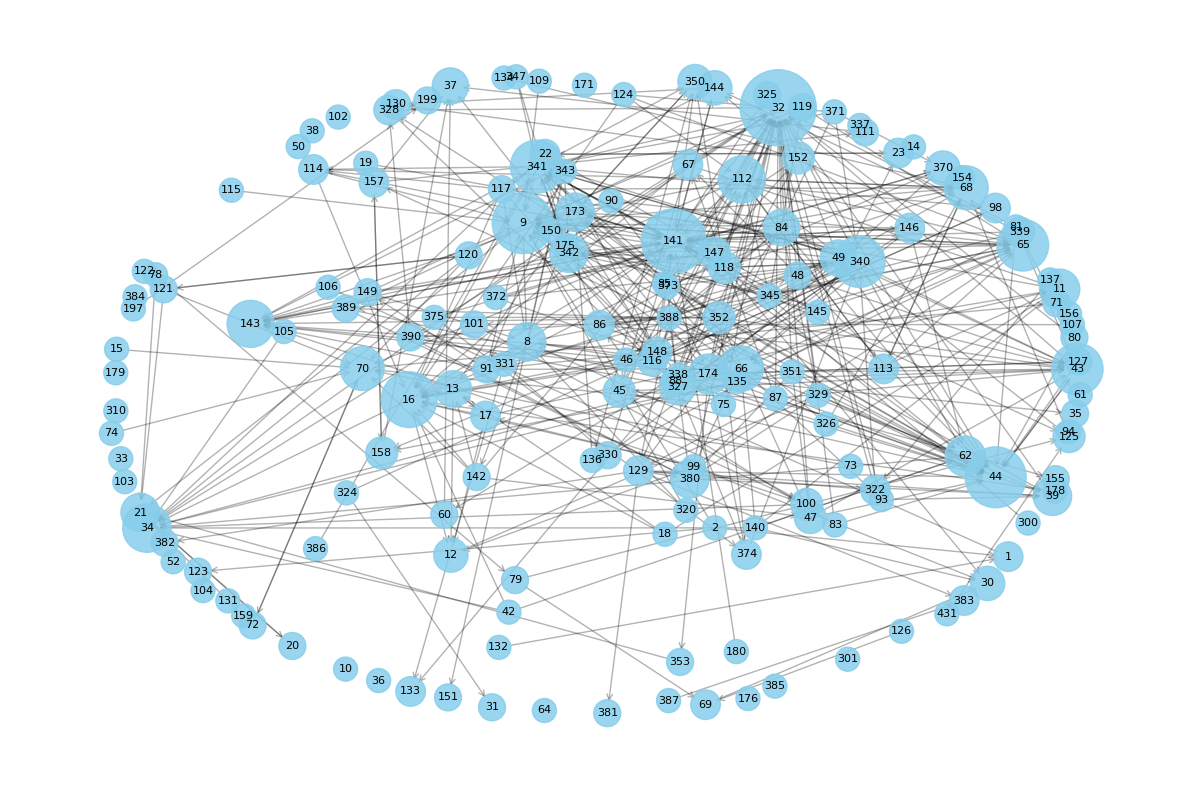

In [11]:
draw_static_network(data, link_type='references')

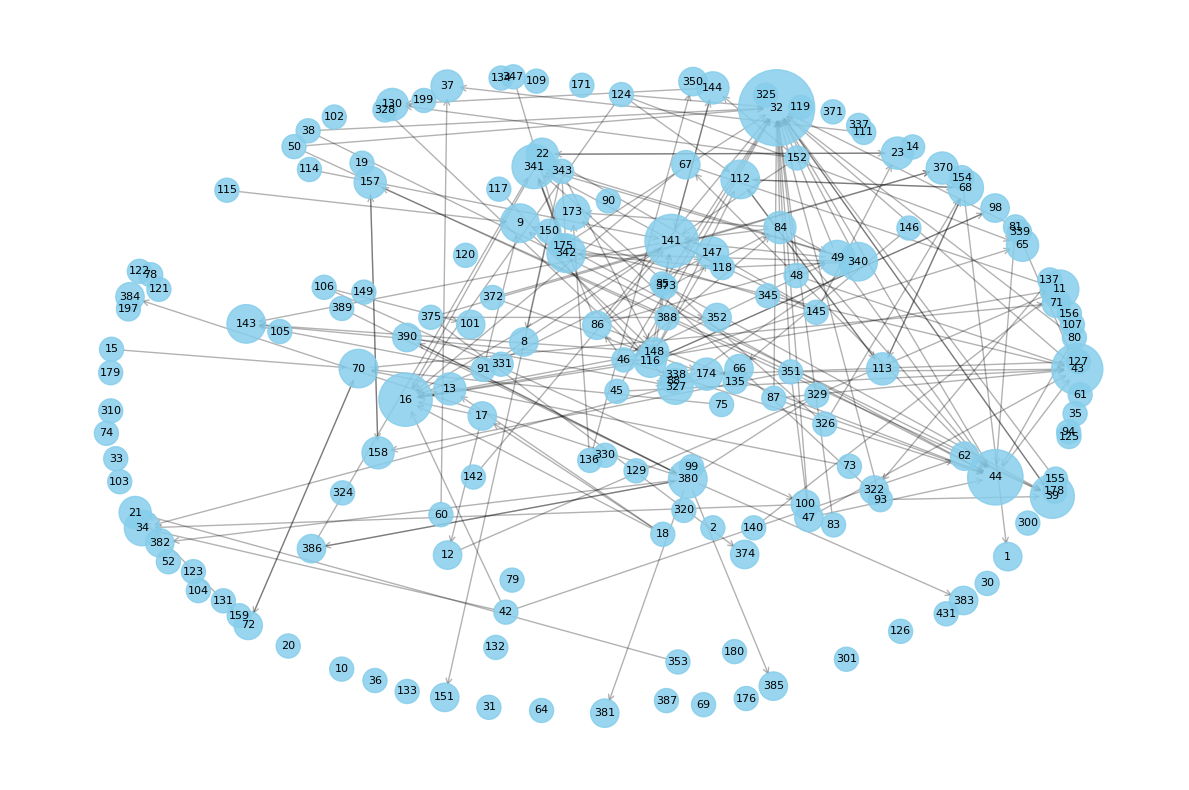

In [12]:
draw_static_network(data, link_type='dependencies')

In [13]:
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch

def draw_preamble_network(data, color_by='group'):
    G = nx.DiGraph()

    # Add nodes with attributes
    for node in data['nodes']:
        G.add_node(
            node['id'],
            group=node.get('group'),
            status=node.get('status')
        )

    # Define the link types to combine
    preamble_links = ['requires', 'replaces', 'superseded_by']

    # Add edges and tag them with their link type
    for link_type in preamble_links:
        for link in data['links'].get(link_type, []):
            G.add_edge(link['source'], link['target'], link_type=link_type)

    # Layout
    pos = nx.spring_layout(G, k=0.5, iterations=100, seed=42)

    # --- Node coloring ---
    attr_values = list(set(nx.get_node_attributes(G, color_by).values()))
    attr_colors = plt.cm.tab10.colors
    attr_map = {attr: attr_colors[i % len(attr_colors)] for i, attr in enumerate(attr_values)}

    color_values = [
        attr_map.get(G.nodes[n].get(color_by), (0.5, 0.5, 0.5))
        for n in G.nodes
    ]

    # Draw nodes
    plt.figure(figsize=(12, 8))
    nx.draw_networkx_nodes(G, pos, node_size=300, node_color=color_values, alpha=0.85)
    nx.draw_networkx_labels(G, pos, font_size=8)

    # --- Edge styling by link_type ---
    edge_styles = {
        'requires': {'style': 'solid', 'color': 'black'},
        'replaces': {'style': 'dashed', 'color': 'red'},
        'superseded_by': {'style': 'dotted', 'color': 'blue'}
    }

    for link_type, style in edge_styles.items():
        edgelist = [(u, v) for u, v, d in G.edges(data=True) if d.get('link_type') == link_type]
        nx.draw_networkx_edges(
            G, pos,
            edgelist=edgelist,
            style=style['style'],
            edge_color=style['color'],
            arrowstyle='->',
            arrows=True,
            alpha=0.6
        )

    # --- Legends ---
    # Node legend
    node_legend = [
        Line2D([0], [0], marker='o', color='w', label=str(attr),
               markerfacecolor=color, markersize=10)
        for attr, color in attr_map.items()
    ]
    plt.legend(handles=node_legend, title=color_by.capitalize(), loc='upper left')

    # Edge legend
    edge_legend = [
        Line2D([0], [0], color=style['color'], linestyle=style['style'], label=lt)
        for lt, style in edge_styles.items()
    ]
    plt.legend(handles=node_legend + edge_legend, loc='best', title='Legend')

    plt.title("BIP Network - Preamble")
    plt.axis('off')
    plt.tight_layout()
    plt.show()


In [14]:
def print_top_central_nodes(G):
    print("Top 5 Nodes by Centrality Measures:\n")

    # In-degree centrality
    in_deg = sorted(nx.in_degree_centrality(G).items(), key=lambda x: x[1], reverse=True)
    print("In-Degree Centrality:")
    for n, c in in_deg[:5]:
        print(f"  {n}: {c:.4f}")

    # Out-degree centrality
    out_deg = sorted(nx.out_degree_centrality(G).items(), key=lambda x: x[1], reverse=True)
    print("\nOut-Degree Centrality:")
    for n, c in out_deg[:5]:
        print(f"  {n}: {c:.4f}")

    # Betweenness
    btw = sorted(nx.betweenness_centrality(G).items(), key=lambda x: x[1], reverse=True)
    print("\nBetweenness Centrality:")
    for n, c in btw[:5]:
        print(f"  {n}: {c:.4f}")

    # PageRank
    pr = sorted(nx.pagerank(G).items(), key=lambda x: x[1], reverse=True)
    print("\nPageRank:")
    for n, c in pr[:5]:
        print(f"  {n}: {c:.4f}")


In [15]:
G = nx.DiGraph()

# Add nodes and edges from your data
for node in data['nodes']:
    G.add_node(
        node['id'],
        group=node.get('group'),
        compliance_score=node.get('compliance_score', 0)
    )

for link in data['links'].get('dependencies', []):  # or other link_type
    G.add_edge(link['source'], link['target'])


In [16]:
print_top_central_nodes(G)

Top 5 Nodes by Centrality Measures:

In-Degree Centrality:
  32: 0.1307
  44: 0.0625
  16: 0.0568
  141: 0.0568
  43: 0.0511

Out-Degree Centrality:
  380: 0.0398
  351: 0.0341
  116: 0.0341
  84: 0.0284
  46: 0.0284

Betweenness Centrality:
  141: 0.0020
  16: 0.0014
  380: 0.0014
  341: 0.0010
  340: 0.0010

PageRank:
  32: 0.1522
  39: 0.1364
  112: 0.0219
  68: 0.0215
  113: 0.0208


In [34]:
G = nx.DiGraph()

# Add nodes and edges from your data
for node in data['nodes']:
    G.add_node(
        node['id'],
        group=node.get('group'),
        compliance_score=node.get('compliance_score', 0)
    )

for link in data['links'].get('references', []):  # or other link_type
    G.add_edge(link['source'], link['target'])

In [35]:
print_top_central_nodes(G)

Top 5 Nodes by Centrality Measures:

In-Degree Centrality:
  32: 0.1989
  141: 0.1364
  44: 0.1193
  9: 0.1193
  16: 0.0966

Out-Degree Centrality:
  141: 0.0625
  388: 0.0568
  341: 0.0568
  352: 0.0511
  129: 0.0511

Betweenness Centrality:
  141: 0.0312
  341: 0.0171
  173: 0.0113
  340: 0.0085
  174: 0.0080

PageRank:
  34: 0.0571
  21: 0.0441
  32: 0.0414
  9: 0.0396
  20: 0.0395


In [17]:
def compute_graph_depth(G):
    longest_path_length = 0
    for node in G.nodes:
        if G.in_degree(node) == 0:  # root node
            lengths = nx.single_source_shortest_path_length(G, node)
            max_length = max(lengths.values(), default=0)
            longest_path_length = max(longest_path_length, max_length)
    return longest_path_length


In [18]:
depth = compute_graph_depth(G)
print(f"Graph Depth: {depth}")

Graph Depth: 6


In [19]:
def find_circular_dependencies(data, link_type='references'):
    G = nx.DiGraph()

    for node in data['nodes']:
        G.add_node(node['id'])

    for link in data['links'].get(link_type, []):
        G.add_edge(link['source'], link['target'])

    cycles = list(nx.simple_cycles(G))

    if cycles:
        print(f"⚠️ Found {len(cycles)} circular dependencies:")
        for i, cycle in enumerate(cycles, 1):
            print(f"  Cycle {i}: {' → '.join(map(str, cycle))} → {cycle[0]}")
    else:
        print("✅ No circular dependencies found.")


In [20]:
find_circular_dependencies(data, link_type='replaces')

✅ No circular dependencies found.


In [21]:
find_circular_dependencies(data, link_type='requires')

✅ No circular dependencies found.


In [22]:
find_circular_dependencies(data, link_type='references')

⚠️ Found 49 circular dependencies:
  Cycle 1: 120 → 121 → 120
  Cycle 2: 23 → 22 → 23
  Cycle 3: 127 → 174 → 127
  Cycle 4: 158 → 157 → 158
  Cycle 5: 118 → 340 → 118
  Cycle 6: 118 → 340 → 327 → 341 → 118
  Cycle 7: 118 → 340 → 327 → 342 → 341 → 118
  Cycle 8: 118 → 340 → 341 → 118
  Cycle 9: 118 → 341 → 118
  Cycle 10: 118 → 341 → 340 → 118
  Cycle 11: 118 → 341 → 342 → 340 → 118
  Cycle 12: 118 → 342 → 340 → 118
  Cycle 13: 118 → 342 → 340 → 327 → 341 → 118
  Cycle 14: 118 → 342 → 340 → 341 → 118
  Cycle 15: 118 → 342 → 341 → 118
  Cycle 16: 118 → 342 → 341 → 340 → 118
  Cycle 17: 340 → 327 → 340
  Cycle 18: 340 → 327 → 341 → 340
  Cycle 19: 340 → 327 → 341 → 342 → 340
  Cycle 20: 340 → 327 → 342 → 340
  Cycle 21: 340 → 327 → 342 → 341 → 340
  Cycle 22: 340 → 341 → 340
  Cycle 23: 340 → 341 → 342 → 340
  Cycle 24: 341 → 342 → 341
  Cycle 25: 98 → 116 → 98
  Cycle 26: 152 → 141 → 146 → 152
  Cycle 27: 152 → 144 → 141 → 146 → 152
  Cycle 28: 142 → 141 → 173 → 142
  Cycle 29: 141 → 143

In [23]:
find_circular_dependencies(data, link_type='dependencies')

⚠️ Found 14 circular dependencies:
  Cycle 1: 98 → 116 → 98
  Cycle 2: 112 → 68 → 112
  Cycle 3: 112 → 68 → 113 → 112
  Cycle 4: 112 → 113 → 68 → 112
  Cycle 5: 112 → 113 → 112
  Cycle 6: 68 → 113 → 68
  Cycle 7: 23 → 22 → 23
  Cycle 8: 72 → 70 → 72
  Cycle 9: 158 → 157 → 158
  Cycle 10: 390 → 380 → 390
  Cycle 11: 380 → 386 → 380
  Cycle 12: 144 → 141 → 144
  Cycle 13: 341 → 342 → 341
  Cycle 14: 32 → 39 → 32


In [24]:
def build_graph(data, link_type='references'):
    G = nx.DiGraph()
    for node in data['nodes']:
        G.add_node(
            node['id'],
            group=node.get('group'),
            compliance_score=node.get('compliance_score', 0)
        )
    for link in data['links'].get(link_type, []):
        G.add_edge(link['source'], link['target'])
    return G



In [25]:
G = build_graph(data)
isolated_nodes = list(nx.isolates(G))
print(f"Number of isolated nodes: {len(isolated_nodes)}")
print("Isolated nodes:", isolated_nodes)

Number of isolated nodes: 26
Isolated nodes: ['122', '159', '179', '102', '10', '50', '154', '103', '94', '104', '61', '36', '14', '385', '38', '171', '131', '310', '384', '337', '301', '156', '52', '64', '33', '176']


In [26]:
G = build_graph(data,'dependencies')
isolated_nodes = list(nx.isolates(G))
print(f"Number of isolated nodes: {len(isolated_nodes)}")
print("Isolated nodes:", isolated_nodes)

Number of isolated nodes: 67
Isolated nodes: ['134', '88', '122', '30', '159', '180', '179', '102', '339', '10', '338', '103', '178', '197', '119', '31', '123', '135', '94', '387', '104', '20', '132', '431', '61', '36', '149', '325', '373', '324', '109', '125', '133', '99', '105', '129', '345', '2', '14', '79', '331', '171', '126', '74', '131', '35', '388', '19', '330', '371', '78', '310', '107', '337', '120', '69', '90', '301', '300', '156', '52', '64', '121', '33', '199', '176', '320']


In [27]:
#apply graph comparison algorithms: graphedit distance

In [28]:
total_links_preamble = sum(
    len(data['links'].get(lt, []))
    for lt in ['requires', 'superseded_by', 'replaces']
)

In [29]:
print(total_links_preamble)

20


In [30]:
total_links_regex = sum(
    len(data['links'].get(lt, []))
    for lt in ['references']
)

In [31]:
print(total_links_regex)

441


In [32]:
total_links_llm = sum(
    len(data['links'].get(lt, []))
    for lt in ['dependencies']
)

In [33]:
print(total_links_llm)

181
